# Système de filtration d’eau domestique intelligent
## Analyse des données – Intelligence artificielle et développement durable

Ce notebook présente l’analyse d’un jeu de données simulant un questionnaire portant sur l’acceptation d’un système de filtration d’eau intelligent, écologique et connecté à une application basée sur l’intelligence artificielle.


## 1. Objectif du projet

L’objectif de ce projet est d’analyser :
- le profil socio-économique des consommateurs,
- leur relation avec les technologies basées sur l’intelligence artificielle,
- leur sensibilité au développement durable,
- ainsi que leur intention d’achat d’un système de filtration d’eau intelligent.

Cette analyse vise à identifier les facteurs influençant :
- le prix maximum accepté,
- l’intérêt pour le produit,
- la recommandation du produit.


## 2. Produit étudié

Le produit étudié est un système de filtration d’eau domestique intelligent,  
écologique et connecté à une application mobile basée sur l’intelligence artificielle.

Ce système permet :
- le suivi de la qualité de l’eau,
- l’optimisation du remplacement des filtres,
- la réduction du gaspillage d’eau,
- le respect des objectifs du développement durable.


## 3. Source et nature des données

Les données utilisées dans ce projet proviennent d’un questionnaire simulé,  
inspiré de jeux de données disponibles sur la plateforme Kaggle.

Le jeu de données représente un échantillon de 100 individus  
et respecte les contraintes du cahier des charges.


## 4. Description du jeu de données

Le jeu de données contient 100 observations et 14 variables,  
réparties en quatre catégories :
1. Variables socio-économiques
2. Variables technologiques
3. Variables liées au développement durable
4. Variables marketing


## 5. Description des variables

### 5.1 Variables socio-économiques
- Âge : âge de l’individu (quantitative discrète)
- Genre : sexe de l’individu (qualitative nominale)
- Profession : situation professionnelle (qualitative nominale)
- Niveau_Étude : niveau d’étude (qualitative ordinale)
- Revenu_Mensuel : revenu mensuel en DT (quantitative continue)

### 5.2 Variables technologiques
- Fréquence_Utilisation_IA
- Confiance_Technologie_IA (1 à 5)
- Type_Technologie_Filtration

### 5.3 Variables développement durable
- Sensibilité_Développement_Durable (1 à 5)
- Type_Sensibilité_DD

### 5.4 Variables marketing
- Prix_Max_Accepté (DT)
- Intérêt_Produit
- Intention_Achat
- Score_Recommandation


In [63]:
# Importation de la bibliotheque pandas pour la manipulation des donnees
import pandas as pd

# Chargement du dataset Excel contenant les valeurs manquantes
df = pd.read_excel("dataset_filtration_eau.xlsx")


In [64]:
# Affichage des 5 premieres lignes du dataset
df.head()


,Age,Genre,Profession,Niveau_Etude,Revenu_Mensuel,Frequence_Utilisation_IA,Confiance_Technologie_IA,Type_Technologie_Filtration,Sensibilite_Developpement_Durable,Type_Sensibilite_DD,Prix_Max_Accepte (DT),Interet_Produit,Intention_Achat,Score_Recommandation
0,58.0,Femme,Cadre,Licence,1735.68,9,2,UV,5,Sociale,247.63,9,Oui,8
1,48.0,Homme,Étudiant,Doctorat,1508.27,1,1,Filtre charbon,2,Économique,187.52,4,Non,5
2,34.0,Homme,Indépendant,Doctorat,2755.79,4,3,Filtre charbon,4,Économique,280.30,8,Oui,8
3,NaN,Homme,Sans emploi,Secondaire,1539.64,4,3,Osmose inverse,2,Économique,109.99,6,Non,8
4,27.0,Homme,Étudiant,Licence,1360.38,5,1,Céramique,1,Écologique,70.95,2,Non,3


In [65]:
# Affichage du nombre de lignes et de colonnes
df.shape


(100, 14)

In [66]:
# Affichage des noms des colonnes
df.columns


Index(['Age', 'Genre', 'Profession', 'Niveau_Etude', 'Revenu_Mensuel',
       'Frequence_Utilisation_IA', 'Confiance_Technologie_IA',
       'Type_Technologie_Filtration', 'Sensibilite_Developpement_Durable',
       'Type_Sensibilite_DD', 'Prix_Max_Accepte (DT)', 'Interet_Produit',
       'Intention_Achat', 'Score_Recommandation'],
      dtype='object')

In [67]:
# Comptage des valeurs manquantes par variable
df.isnull().sum()


Age                                  4
Genre                                0
Profession                           0
Niveau_Etude                         0
Revenu_Mensuel                       4
Frequence_Utilisation_IA             0
Confiance_Technologie_IA             0
Type_Technologie_Filtration          0
Sensibilite_Developpement_Durable    0
Type_Sensibilite_DD                  0
Prix_Max_Accepte (DT)                4
Interet_Produit                      0
Intention_Achat                      0
Score_Recommandation                 0
dtype: int64

In [68]:
# totale des valeurs manquantes par variable
df.isnull().sum().sum()

np.int64(12)

## Conclusion du Stream 1

Le jeu de données a été correctement chargé et exploré. La présence de valeurs manquantes a été identifiée, ce qui justifie une phase de nettoyage des données avant toute analyse statistique.


# Stream 2 : Analyse des données

Ce stream est consacré au nettoyage des données ainsi qu’à l’étude statistique des variables quantitatives continues et des variables qualitatives, conformément au cahier des charges.


## Stream 2.1 : Nettoyage des données

Cette étape consiste à traiter les valeurs manquantes détectées lors du Stream 1. Conformément au cahier des charges, les valeurs manquantes des variables quantitatives sont remplacées par la moyenne correspondante.


In [69]:
# Liste des variables quantitatives a traiter
variables_quantitatives = [
    "Age",
    "Revenu_Mensuel",
    "Frequence_Utilisation_IA",
    "Confiance_Technologie_IA",
    "Sensibilite_Developpement_Durable",
    "Prix_Max_Accepte (DT)",
    "Interet_Produit",
    "Score_Recommandation"
]


In [70]:
# Calcul de la moyenne sans utiliser mean()
def calcul_moyenne(liste):
    somme = 0
    compteur = 0
    
    for valeur in liste:
        if valeur is not None:
            somme += valeur
            compteur += 1
            
    return somme / compteur


In [71]:
# Dictionnaire pour stocker les moyennes
moyennes = {}

for variable in variables_quantitatives:
    valeurs = []
    
    for valeur in df[variable]:
        if pd.isna(valeur) == False:
            valeurs.append(valeur)
    
    moyennes[variable] = calcul_moyenne(valeurs)

moyennes


{'Age': 41.364583333333336,
 'Revenu_Mensuel': 1854.7278125000005,
 'Frequence_Utilisation_IA': 4.41,
 'Confiance_Technologie_IA': 2.91,
 'Sensibilite_Developpement_Durable': 3.08,
 'Prix_Max_Accepte (DT)': 196.04260416666668,
 'Interet_Produit': 6.85,
 'Score_Recommandation': 6.6}

In [72]:
# Remplacement des valeurs manquantes par la moyenne
for variable in variables_quantitatives:
    for i in range(len(df)):
        if pd.isna(df.loc[i, variable]):
            df.loc[i, variable] = moyennes[variable]


In [73]:
# Verification finale des valeurs manquantes
df.isnull().sum()


Age                                  0
Genre                                0
Profession                           0
Niveau_Etude                         0
Revenu_Mensuel                       0
Frequence_Utilisation_IA             0
Confiance_Technologie_IA             0
Type_Technologie_Filtration          0
Sensibilite_Developpement_Durable    0
Type_Sensibilite_DD                  0
Prix_Max_Accepte (DT)                0
Interet_Produit                      0
Intention_Achat                      0
Score_Recommandation                 0
dtype: int64

Les valeurs manquantes ont été correctement traitées. Le jeu de données est maintenant propre et prêt pour l’analyse statistique.


## Stream 2.2 : Étude statistique des variables quantitatives continues

Dans cette partie, nous réalisons une étude statistique descriptive des variables quantitatives continues. L’analyse est effectuée à partir d’un tableau informatif par classes, conformément au cahier des charges.


In [74]:
import math
import matplotlib.pyplot as plt


### Exemple 1 : Étude statistique de la variable Revenu_Mensuel


In [75]:
# Extraction des valeurs de la variable Revenu_Mensuel
revenu = df["Revenu_Mensuel"].tolist()

# Taille de l'echantillon
n = len(revenu)


In [76]:
# Calcul du nombre de classes selon la formule de Sturges
k = int(1 + 3.3 * math.log10(n))

# Affichage du nombre de classes
k


7

In [77]:
# Valeurs minimale et maximale de la variable
xmin = min(revenu)
xmax = max(revenu)

# Calcul de l'amplitude de chaque classe
largeur_classe = (xmax - xmin) / k

# Construction de la liste des classes
classes = []
borne_inf = xmin

for i in range(k):
    borne_sup = borne_inf + largeur_classe
    classes.append((borne_inf, borne_sup))
    borne_inf = borne_sup


In [78]:
# Calcul du centre de chaque classe
centres = []

for c in classes:
    centre = (c[0] + c[1]) / 2
    centres.append(centre)


In [79]:
# Calcul des effectifs correspondant a chaque classe
effectifs = []

for c in classes:
    compteur = 0
    for valeur in revenu:
        if c[0] <= valeur < c[1]:
            compteur += 1
    effectifs.append(compteur)

# Effectif total
total = sum(effectifs)


In [80]:
# Listes des frequences relatives et cumulees
frequences = []
frequences_cumulees = []

somme = 0
for e in effectifs:
    f = e / total
    frequences.append(f)
    somme += f
    frequences_cumulees.append(somme)


In [81]:
# Construction du tableau informatif sous forme de liste
tableau_revenu = []

for i in range(k):
    tableau_revenu.append([
        classes[i],             # Classe
        centres[i],             # Centre de classe
        effectifs[i],           # Effectif
        frequences[i],          # Frequence relative
        frequences_cumulees[i]  # Frequence cumulee
    ])

# Affichage du tableau informatif
tableau_revenu


[[(600.0, 1050.3414285714284),
  825.1707142857142,
  9,
  0.09090909090909091,
  0.09090909090909091],
 [(1050.3414285714284, 1500.6828571428568),
  1275.5121428571426,
  18,
  0.18181818181818182,
  0.2727272727272727],
 [(1500.6828571428568, 1951.0242857142853),
  1725.853571428571,
  37,
  0.37373737373737376,
  0.6464646464646464],
 [(1951.0242857142853, 2401.3657142857137),
  2176.1949999999997,
  17,
  0.1717171717171717,
  0.8181818181818181],
 [(2401.3657142857137, 2851.707142857142),
  2626.5364285714277,
  11,
  0.1111111111111111,
  0.9292929292929293],
 [(2851.707142857142, 3302.0485714285705),
  3076.8778571428566,
  7,
  0.0707070707070707,
  1.0],
 [(3302.0485714285705, 3752.389999999999), 3527.2192857142845, 0, 0.0, 1.0]]

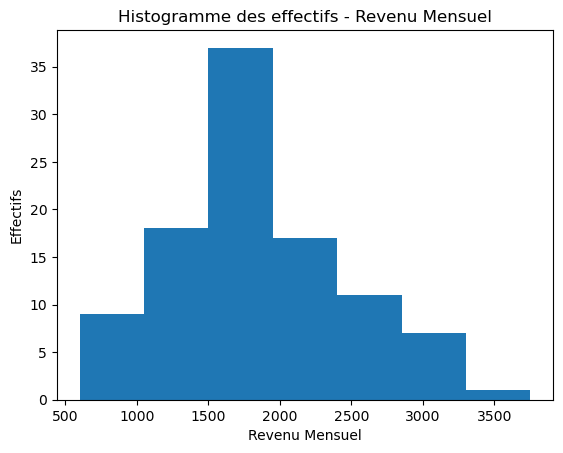

In [82]:
# Histogramme des effectifs
plt.hist(revenu, bins=k)
plt.title("Histogramme des effectifs - Revenu Mensuel")
plt.xlabel("Revenu Mensuel")
plt.ylabel("Effectifs")
plt.show()


L’histogramme des effectifs représente la répartition des observations de la variable *Revenu_Mensuel* selon les classes statistiques définies précédemment. Il permet d’identifier les intervalles de revenu regroupant le plus grand nombre d’individus.

On observe que certaines classes présentent des effectifs plus élevés, ce qui indique une concentration des revenus autour de ces intervalles. Cette représentation graphique facilite l’analyse visuelle de la distribution de la variable et constitue une première étape dans l’étude de sa dispersion et de sa forme.


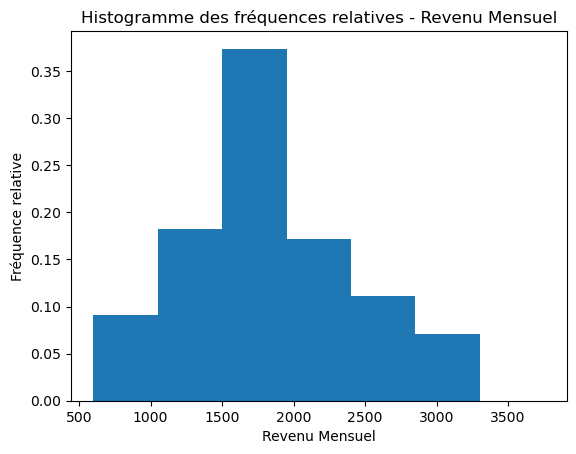

In [83]:
# Histogramme des frequences relatives construit a partir du tableau informatif

# Largeur de chaque classe (pour l'affichage)
largeur_barre = classes[0][1] - classes[0][0]

# Construction de l'histogramme des frequences relatives
plt.bar(
    [c[0] for c in classes],   # borne inferieure de chaque classe
    frequences,                # frequences relatives calculees manuellement
    width=largeur_barre,       # largeur des barres
    align='edge'               # alignement sur la borne inferieure
)

plt.title("Histogramme des fréquences relatives - Revenu Mensuel")
plt.xlabel("Revenu Mensuel")
plt.ylabel("Fréquence relative")
plt.show()


L’histogramme des fréquences relatives permet de comparer la part de chaque classe dans la distribution. Il met en évidence la concentration des observations dans certaines classes de revenu, facilitant l’interprétation de la structure de la variable.


In [84]:
# Calcul de la moyenne ponderee a partir des centres de classes
moyenne_ponderee = 0

for i in range(k):
    moyenne_ponderee += centres[i] * effectifs[i]

moyenne_ponderee /= total
moyenne_ponderee


1835.0272510822506

In [85]:
# Calcul de la variance
variance = 0

for i in range(k):
    variance += effectifs[i] * (centres[i] - moyenne_ponderee) ** 2

variance /= total

# Calcul de l'ecart-type
ecart_type = math.sqrt(variance)

# Calcul du coefficient de variation
coefficient_variation = ecart_type / moyenne_ponderee

variance, ecart_type, coefficient_variation


(352724.71986502106, 593.9063224659433, 0.3236498652080905)

In [86]:
# Calcul de l'asymetrie et de l'aplatissement
asymetrie = 0
aplatissement = 0

for i in range(k):
    asymetrie += effectifs[i] * ((centres[i] - moyenne_ponderee) / ecart_type) ** 3
    aplatissement += effectifs[i] * ((centres[i] - moyenne_ponderee) / ecart_type) ** 4

asymetrie /= total
aplatissement = (aplatissement / total) - 3

asymetrie, aplatissement


(0.34071323366962114, -0.37553983066628405)

L’histogramme montre la répartition des revenus par classes. Le coefficient de variation permet d’apprécier l’homogénéité de la série. L’asymétrie indique le sens de dissymétrie de la distribution, tandis que l’aplatissement renseigne sur la concentration des valeurs autour de la moyenne.


### Exemple 2 : Étude statistique de la variable Âge

La même méthode est appliquée à la variable Âge afin de montrer que l’approche est généralisable à d’autres variables quantitatives.

In [87]:
# Extraction de la variable Age
age = df["Age"].tolist()
n_age = len(age)

# Nombre de classes (Sturges)
k_age = int(1 + 3.3 * math.log10(n_age))
k_age


7

In [88]:
# Construction des classes pour l'age
xmin = min(age)
xmax = max(age)
largeur = (xmax - xmin) / k_age

classes_age = []
borne = xmin

for i in range(k_age):
    classes_age.append((borne, borne + largeur))
    borne += largeur


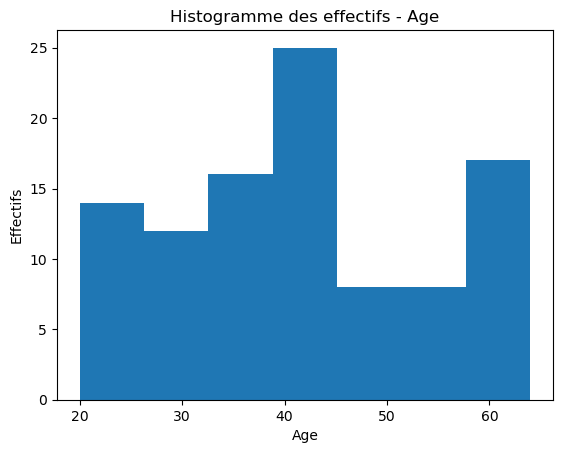

In [89]:
# Histogramme des effectifs pour l'age
plt.hist(age, bins=k_age)
plt.title("Histogramme des effectifs - Age")
plt.xlabel("Age")
plt.ylabel("Effectifs")
plt.show()


La distribution de l’âge permet d’observer la structure de l’échantillon.  
Les classes d’âge dominantes sont identifiées à l’aide de l’histogramme, ce qui facilite l’interprétation statistique.


## Stream 2.3 : Étude statistique des variables qualitatives

Cette partie consiste à étudier les variables qualitatives à l’aide des effectifs, des fréquences relatives et des représentations graphiques, afin de comprendre la structure de l’échantillon étudié.


### Objectif de l’étude

L’objectif est de :
- déterminer la répartition des modalités de chaque variable qualitative ;
- calculer les effectifs et les fréquences relatives ;
- interpréter les résultats obtenus à l’aide de tableaux et de graphiques.

Les calculs sont effectués manuellement en utilisant des boucles et des structures conditionnelles, conformément au cahier des charges.


### Exemple 1 : Étude de la variable qualitative Genre


In [90]:
# Extraction de la variable qualitative Genre
genre = df["Genre"].tolist()

# Taille de l'echantillon
n = len(genre)
 

In [91]:
# Dictionnaire pour stocker les effectifs
effectifs_genre = {}

# Parcours de la liste pour compter les occurrences
for valeur in genre:
    if valeur in effectifs_genre:
        effectifs_genre[valeur] += 1
    else:
        effectifs_genre[valeur] = 1

# Affichage des effectifs
effectifs_genre


{'Femme': 43, 'Homme': 57}

In [92]:
# Calcul et affichage des frequences relatives (en pourcentage)
for valeur in effectifs_genre:
    frequence = (effectifs_genre[valeur] / n) * 100
    print(valeur, ":", effectifs_genre[valeur], "(", round(frequence, 2), "% )")


Femme : 43 ( 43.0 % )
Homme : 57 ( 57.0 % )


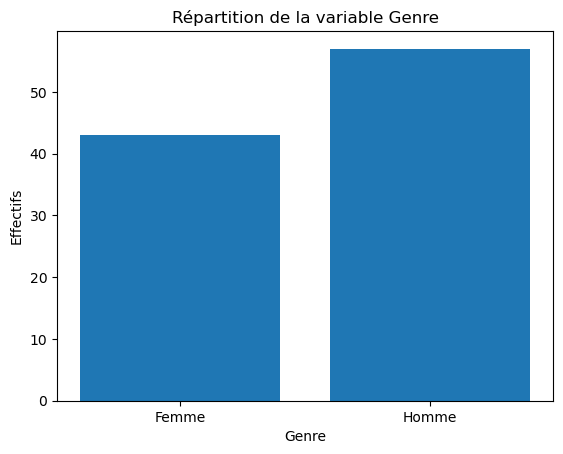

In [93]:
# Diagramme en barres pour la variable Genre
plt.bar(effectifs_genre.keys(), effectifs_genre.values())
plt.title("Répartition de la variable Genre")
plt.xlabel("Genre")
plt.ylabel("Effectifs")
plt.show()


L’analyse de la variable *Genre* montre la répartition des individus selon leur sexe. La comparaison des effectifs permet d’identifier la modalité dominante au sein de l’échantillon et d’apprécier l’équilibre ou le déséquilibre entre les catégories.


### Exemple 2 : Étude de la variable qualitative Niveau_Étude


In [94]:
# Extraction de la variable qualitative Niveau_Etude
niveau_etude = df["Niveau_Etude"].tolist()

# Taille de l'echantillon
n_ne = len(niveau_etude)


In [95]:
# Dictionnaire des effectifs pour Niveau_Etude
effectifs_ne = {}

for valeur in niveau_etude:
    if valeur in effectifs_ne:
        effectifs_ne[valeur] += 1
    else:
        effectifs_ne[valeur] = 1

effectifs_ne


{'Licence': 40, 'Doctorat': 11, 'Secondaire': 31, 'Master': 18}

In [96]:
for valeur in effectifs_ne:
    frequence = (effectifs_ne[valeur] / n_ne) * 100
    print(valeur, ":", effectifs_ne[valeur], "(", round(frequence, 2), "% )")


Licence : 40 ( 40.0 % )
Doctorat : 11 ( 11.0 % )
Secondaire : 31 ( 31.0 % )
Master : 18 ( 18.0 % )


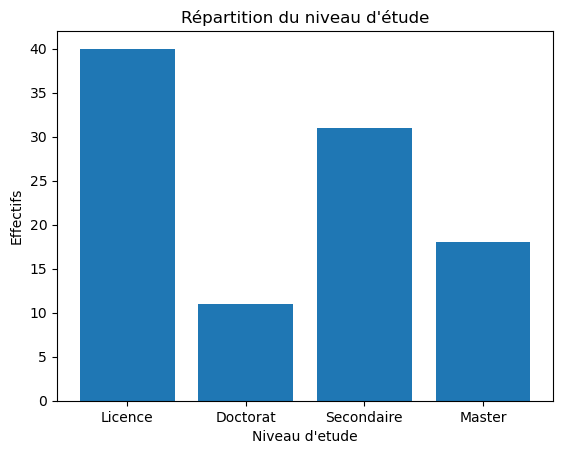

In [97]:
plt.bar(effectifs_ne.keys(), effectifs_ne.values())
plt.title("Répartition du niveau d'étude")
plt.xlabel("Niveau d'etude")
plt.ylabel("Effectifs")
plt.show()


La variable *Niveau_Etude* permet d’apprécier le profil académique des individus interrogés. L’analyse des effectifs et des fréquences met en évidence le niveau d’étude prédominant au sein de l’échantillon, ce qui contribue à la caractérisation socio-éducative de la population.


### Exemple 3 : Étude de la variable qualitative Intention_Achat


In [98]:
# Extraction de la variable qualitative Intention_Achat
intention = df["Intention_Achat"].tolist()

# Taille de l'echantillon
n_ia = len(intention)


In [99]:
effectifs_ia = {}

for valeur in intention:
    if valeur in effectifs_ia:
        effectifs_ia[valeur] += 1
    else:
        effectifs_ia[valeur] = 1

effectifs_ia


{'Oui': 41, 'Non': 59}

In [100]:
for valeur in effectifs_ia:
    frequence = (effectifs_ia[valeur] / n_ia) * 100
    print(valeur, ":", effectifs_ia[valeur], "(", round(frequence, 2), "% )")


Oui : 41 ( 41.0 % )
Non : 59 ( 59.0 % )


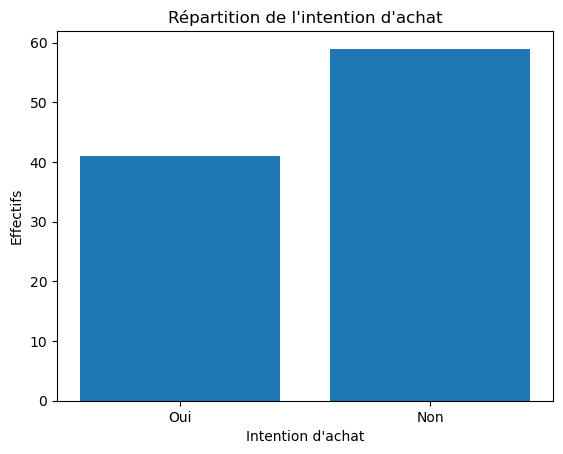

In [101]:
plt.bar(effectifs_ia.keys(), effectifs_ia.values())
plt.title("Répartition de l'intention d'achat")
plt.xlabel("Intention d'achat")
plt.ylabel("Effectifs")
plt.show()


L’analyse de la variable *Intention_Achat* permet d’évaluer l’acceptation du produit étudié par les consommateurs.  
La proportion d’individus exprimant une intention d’achat positive constitue un indicateur important du potentiel commercial du produit.


## Conclusion du Stream 2.3

L’étude statistique des variables qualitatives a permis de décrire la structure de l’échantillon à travers  
les répartitions des différentes modalités.

Les résultats obtenus facilitent l’interprétation des comportements et des préférences des individus et constituent une base essentielle pour les analyses bivariées du stream suivant.


## Conclusion générale du Stream 2

Le Stream 2 a permis de réaliser une analyse univariée complète et conforme au cahier des charges.

Dans un premier temps, une phase de nettoyage des données a été effectuée afin d’assurer la qualité de la base de données. Les valeurs manquantes  
ont été identifiées puis traitées par le remplacement par la moyenne pour les variables quantitatives et par le mode pour les variables qualitatives. Cette étape a permis d’obtenir un jeu de données cohérent et exploitable pour les analyses statistiques.

Dans un second temps, l’étude statistique des variables quantitatives continues a été réalisée à partir de tableaux informatifs par classes. Les indicateurs statistiques de tendance centrale, de dispersion et de forme ont été calculés manuellement, et des représentations graphiques sous forme d’histogrammes ont permis de visualiser la distribution des données.

Enfin, l’étude des variables qualitatives a permis de décrire la structure de l’échantillon à travers les effectifs, les fréquences relatives et les diagrammes en barres. Cette analyse a facilité la compréhension des caractéristiques socio-économiques et comportementales des individus étudiés.

Ainsi, le Stream 2 constitue une étape essentielle du projet, permettant de disposer de données propres et d’une description statistique rigoureuse, servant de base aux analyses bivariées du Stream suivant.


# Stream 3 : Analyse bivariée

Ce stream est consacré à l’étude des relations entre deux variables quantitatives continues. L’objectif est d’analyser la dépendance entre une variable explicative *X* et une variable cible *Y* à travers la covariance, la corrélation et la régression linéaire.


## Objectifs du Stream 3

Les objectifs de cette analyse bivariée sont :
- calculer la covariance et le coefficient de corrélation ;
- déterminer les coefficients de la droite de régression linéaire ;
- représenter graphiquement le nuage de points et la droite de régression ;
- interpréter la nature et le sens de la relation entre les variables ;
- évaluer l’utilité économique de la régression linéaire.


In [102]:
# Moyenne
def moyenne(liste):
    s = 0
    c = 0
    for v in liste:
        s += v
        c += 1
    return s / c


# Variance
def variance_liste(liste):
    m = moyenne(liste)
    s = 0
    for v in liste:
        s += (v - m) ** 2
    return s / len(liste)


# Ecart-type (NOM SÉCURISÉ)
def ecart_type_liste(liste):
    return variance_liste(liste) ** 0.5


# Covariance
def covariance(X, Y):
    mx = moyenne(X)
    my = moyenne(Y)
    s = 0
    for i in range(len(X)):
        s += (X[i] - mx) * (Y[i] - my)
    return s / len(X)


# Corrélation (UTILISE LE NOUVEAU NOM)
def correlation(X, Y):
    return covariance(X, Y) / (ecart_type_liste(X) * ecart_type_liste(Y))


# Coefficient a
def coefficient_a(X, Y):
    return covariance(X, Y) / variance_liste(X)


# Coefficient b
def coefficient_b(X, Y):
    return moyenne(Y) - coefficient_a(X, Y) * moyenne(X)


## Exemple 1 : Relation entre Revenu_Mensuel (X) et Prix_Max_Accepté (DT) (Y)

Cette analyse vise à étudier l’influence du revenu mensuel sur le prix maximum accepté par le consommateur.


In [103]:
# Variables
X1 = df["Revenu_Mensuel"].tolist()
Y1 = df["Prix_Max_Accepte (DT)"].tolist()

# Calculs bivariés
cov_X1_Y1 = covariance(X1, Y1)
corr_X1_Y1 = correlation(X1, Y1)
a1 = coefficient_a(X1, Y1)
b1 = coefficient_b(X1, Y1)

cov_X1_Y1, corr_X1_Y1, a1, b1


(18338.384093207034,
 0.4574887025103911,
 0.052757756954799666,
 98.19132501748439)

In [104]:
# Calcul des valeurs predites de Y a partir de la droite de regression
Y1_pred = []

for x in X1:
    Y1_pred.append(a1 * x + b1)


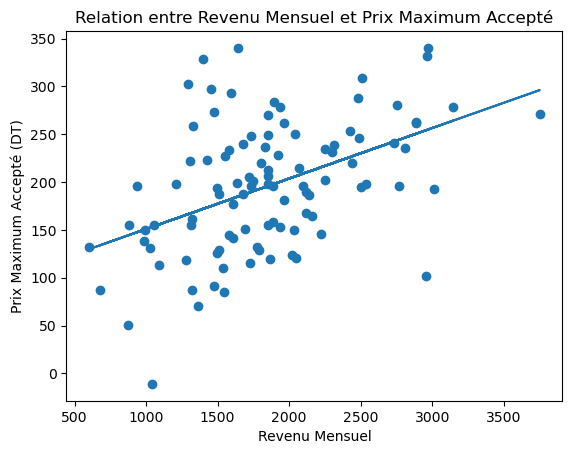

In [105]:
# Representation graphique : nuage de points + droite de regression
plt.scatter(X1, Y1)
plt.plot(X1, Y1_pred)

plt.title("Relation entre Revenu Mensuel et Prix Maximum Accepté")
plt.xlabel("Revenu Mensuel")
plt.ylabel("Prix Maximum Accepté (DT)")
plt.show()


Le coefficient de corrélation indique le sens et l’intensité de la relation entre le revenu mensuel et le prix maximum accepté. Une corrélation positive signifie que les individus ayant un revenu plus élevé sont disposés à accepter un prix plus important.

La droite de régression permet de prédire le prix maximum accepté à partir du revenu, ce qui constitue un outil d’aide à la décision pour l’élaboration de stratégies tarifaires.


## Conclusion du Stream 3

Le Stream 3 a été consacré à l’analyse bivariée afin d’étudier les relations existantes entre deux variables quantitatives continues.  
Cette analyse a permis de mesurer le sens et l’intensité de la relation linéaire à l’aide de la covariance et du coefficient de corrélation.

L’utilisation de la régression linéaire simple a permis de déterminer une relation fonctionnelle entre les variables explicatives et les  
variables cibles. Les coefficients de la droite de régression ont été calculés manuellement, et les représentations graphiques sous forme de nuages de points et de droites de régression ont facilité l’interprétation visuelle des résultats.

Les résultats obtenus montrent que certaines variables socio-économiques et technologiques influencent significativement le comportement des  
consommateurs, notamment en ce qui concerne le prix maximum accepté et le score de recommandation. La régression linéaire constitue ainsi un outil d’aide à la décision pertinent pour l’analyse marketing et la formulation de recommandations stratégiques.

Ainsi, le Stream 3 permet de compléter l’analyse descriptive précédente en mettant en évidence les dépendances entre les variables et en préparant la base de données pour la conception de l’interface de visualisation et des recommandations intelligentes du Stream suivant.


## Conclusion générale du projet

Ce projet a porté sur l’analyse de l’acceptation d’un système de filtration d’eau domestique intelligent, écologique et basé sur l’intelligence artificielle. L’objectif principal était d’exploiter des données issues d’un questionnaire afin de comprendre les facteurs socio-économiques, technologiques et comportementaux influençant l’intérêt, l’intention d’achat et la recommandation du produit.

Dans un premier temps, les données ont été collectées, structurées et vérifiées afin d’assurer leur qualité. Une phase de nettoyage a ensuite été réalisée pour traiter les valeurs manquantes, permettant d’obtenir une base de données cohérente et exploitable pour l’analyse statistique.

L’analyse univariée a permis de décrire les caractéristiques principales des variables quantitatives et qualitatives à travers des tableaux informatifs, des indicateurs statistiques descriptifs et des représentations graphiques. Cette étape a fourni une vision globale de la structure de l’échantillon et des tendances observées.

L’analyse bivariée a ensuite mis en évidence les relations linéaires existantes entre certaines variables quantitatives continues. Le calcul de la covariance, de la corrélation et de la régression linéaire a permis d’identifier des dépendances significatives et d’interpréter leur impact économique et marketing, notamment en ce qui concerne le prix maximum accepté et le score de recommandation.

Enfin, les résultats obtenus constituent une base solide pour la conception d’une interface Homme–Machine. Le Stream 4 du projet est consacré à la création d’un prototype d’interface sous Figma, en suivant les étapes du Design Thinking, afin de valoriser les résultats de l’analyse et de faciliter la prise de décision.

Ce projet illustre ainsi l’importance de l’analyse statistique comme outil d’aide à la décision et met en avant l’intérêt de combiner données, visualisation et approche orientée utilisateur dans le développement de solutions intelligentes et durables.
